In [3]:
import numpy as np
from matplotlib import rc,rcParams
#matplotlib.use('Agg')
import matplotlib.pyplot as plt
from astropy.io import fits
%matplotlib inline 
import os
from astropy.table import Table
from scipy import stats
from astropy.cosmology import Planck18 as cosmo
import astropy.coordinates as coord
from scipy import stats
import statsmodels.api as sm


In [4]:
    def set_rc_params(fontsize=None):

        print("Setting Matplotlib RC parameters...")

        if fontsize is None:
            fontsize=16
        else:
            fontsize=int(fontsize)

        rc('font',**{'family':'serif'})
        rc('text', usetex=True)

        #plt.rcParams.update({'figure.facecolor':'w'})
        plt.rcParams.update({'axes.linewidth': 1.1})
        plt.rcParams.update({'xtick.labelsize': fontsize})
        plt.rcParams.update({'ytick.labelsize': fontsize})
        plt.rcParams.update({'xtick.major.size': 8})
        plt.rcParams.update({'xtick.major.width': 1.1})
        plt.rcParams.update({'xtick.minor.visible': True})
        plt.rcParams.update({'xtick.minor.width': 1.})
        plt.rcParams.update({'xtick.minor.size': 6})
        plt.rcParams.update({'xtick.direction': 'out'})
        plt.rcParams.update({'ytick.major.width': 1.1})
        plt.rcParams.update({'ytick.major.size': 8})
        plt.rcParams.update({'ytick.minor.visible': True})
        plt.rcParams.update({'ytick.minor.width': 1.})
        plt.rcParams.update({'ytick.minor.size':6})
        plt.rcParams.update({'ytick.direction':'out'})
        plt.rcParams.update({'axes.labelsize': fontsize})
        plt.rcParams.update({'axes.titlesize': fontsize})
        plt.rcParams.update({'legend.fontsize': int(fontsize-2)})

        return


In [5]:
set_rc_params(fontsize=16)

Setting Matplotlib RC parameters...


## Define a useful cleaning function

In [4]:
# Let's start by making color-redshift plot for redmagic
def remove_outliers(data, bands):
    # All bands are good <3
    catlen = len(data)
    wg = np.full(catlen, True)

    # Pick out only the good entries!
    for band in bands:
        band_mag = np.ma.getdata(data[band])
        band_bool = (band_mag > -9999) & (band_mag != np.nan) & (band_mag < 27)
        wg *= band_bool

    # percent of galaxies that failed
    pfail = 100-(np.count_nonzero(wg) / catlen * 100)

    # How many failed?
    print(f'RedshiftCalc: {np.count_nonzero(wg)}/{catlen} galaxies',
          f'({100-pfail:.1f}%) have good photometry')
    print(f'RedshiftCalc: removing {pfail:.1f}% of galaxies from data')
    print('')

    return wg

In [ ]:
catalog_path = '/Users/j.mccleary/Research/dusty_halos/catalogs/prep_cat_output'
hiz = Table.read(os.path.join(catalog_path, 'redmagic_hiz_y3_GOLD_JOINED_catalog.fits'))
hidens = Table.read(os.path.join(catalog_path,'redmagic_hidens_y3_GOLD_JOINED_catalog.fits'))


In [ ]:
bands = ['mof_cm_mag_corrected_g', 'mof_cm_mag_corrected_r',
        'mof_cm_mag_corrected_i', 'mof_cm_mag_corrected_z']


wg_hiz = remove_outliers(hiz, bands)
hiz = hiz[wg_hiz]
wg_hidens = remove_outliers(hidens, bands)
hidens = hidens[wg_hidens]

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12,6), tight_layout=True)
axs[0].plot(hidens['zredmagic'], 
            (hidens['mof_cm_mag_corrected_g'] - hidens['mof_cm_mag_corrected_r']), 
            '.', markersize=0.5, color='xkcd:tomato red', label='hidens')
axs[0].plot(hiz['zredmagic'], 
            (hiz['mof_cm_mag_corrected_g'] - hiz['mof_cm_mag_corrected_r']), 
             '.', markersize=0.5, color='xkcd:deep red', label='hilum_hiz')
axs[0].set_ylim(-1,6)
axs[0].legend(markerscale=15, loc='upper left')
axs[0].set_xlabel('Redshift')
axs[0].set_ylabel(r'$g$ - $r$')

axs[1].plot(hidens['zredmagic'], 
            (hidens['mof_cm_mag_corrected_i'] - hidens['mof_cm_mag_corrected_z']), 
            '.', markersize=0.5, color='xkcd:tomato red', label='hidens')
axs[1].plot(hiz['zredmagic'], 
            (hiz['mof_cm_mag_corrected_i'] - hiz['mof_cm_mag_corrected_z']), 
             '.', markersize=0.5, color='xkcd:deep red', label='hilum_hiz')
axs[1].set_ylim(-0.5,1.5)
axs[1].legend(markerscale=15, loc='upper left')
axs[1].set_xlabel('Redshift')
axs[1].set_ylabel(r'$i$ - $z$')

fig.savefig('color_redshift_redmagic.pdf')
fig.savefig('color_redshift_redmagic.png')

## OK, let's try Av histogram

In [42]:
catdir = '/Users/j.mccleary/Research/dusty_halos/dusthalos/output/'
hiz_tcatname = 'redmagic_hiz/dust_correlation_calzetti00_treecorrcat.fits'
hiz_tcatname2 = 'redmagic_hiz/dust_correlation_calzetti00_5zbins_treecorrcat.fits'
hiz_tcatname3 = 'hiz/dust_correlation_calzetti00_9zbins_treecorrcat.fits'

hiz_tcat = Table.read(os.path.join(catdir, hiz_tcatname))
hiz_tcat2 = Table.read(os.path.join(catdir, hiz_tcatname2))
hiz_tcat3 = Table.read(os.path.join(catdir, hiz_tcatname3))

hidens_tcatname = 'redmagic_hidens/dust_correlation_calzetti00_treecorrcat.fits'
hidens_tcatname2 = 'redmagic_hidens/dust_correlation_calzetti00_8zbins_treecorrcat.fits'
hidens_tcatname3 = 'redmagic_hidens/dust_correlation_calzetti00_17zbins_treecorrcat.fits'

hidens_tcat = Table.read(os.path.join(catdir, hidens_tcatname))
hidens_tcat2 = Table.read(os.path.join(catdir, hidens_tcatname2))
hidens_tcat3 = Table.read(os.path.join(catdir, hidens_tcatname3))


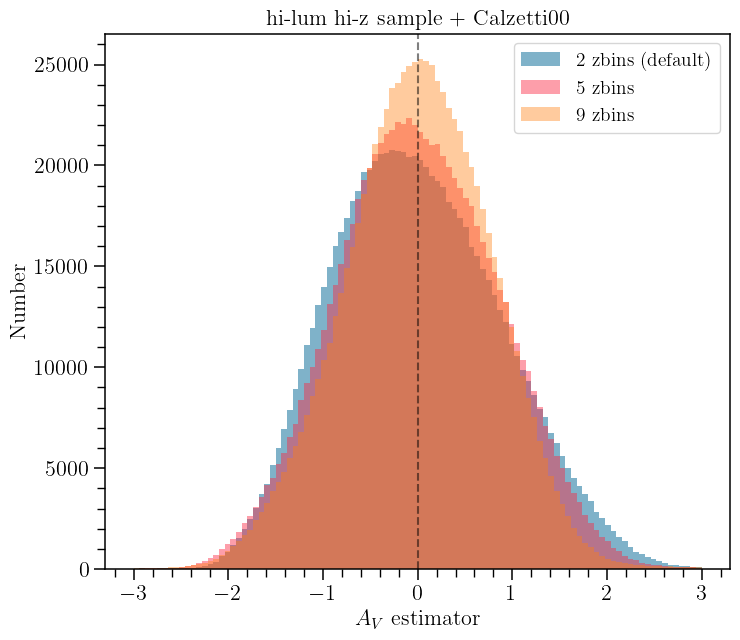

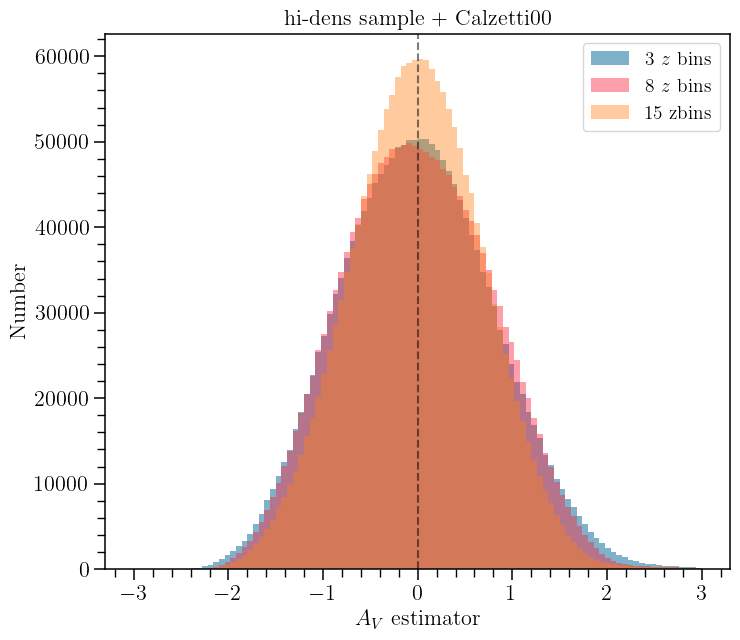

In [59]:
plt.figure(figsize=(7.5,6.5), tight_layout=True)
plt.hist(hiz_tcat['k'], bins=100, range=[-3, 3], histtype='bar', 
        label='2 zbins (default)', alpha=0.5, color='xkcd:peacock blue')
plt.hist(hiz_tcat2['k'], bins=100, range=[-3, 3], histtype='bar', 
        label='5 zbins', color='xkcd:strawberry', alpha=0.45)
plt.hist(hiz_tcat3['k'], bins=100, range=[-3, 3], histtype='bar', 
        label='9 zbins', color='tab:orange', alpha=0.4)

plt.axvline(0, ls='--', color='k', alpha=0.5)
plt.xlabel(r'$A_V$ estimator')
plt.ylabel('Number')
plt.legend()
plt.title(r'hi-lum hi-z sample + Calzetti00')
#plt.savefig('hilum_hiz_Av_hist_Calzetti00.pdf')
plt.savefig('figures/hilum_hiz_Av_hist.png')

###
### Now repeat for hidens
###

plt.figure(figsize=(7.5,6.5), tight_layout=True)
plt.hist(hidens_tcat['k'], bins=100, range=[-3, 3], histtype='bar', 
        label=r'3 $z$ bins', alpha=0.5, color='xkcd:peacock blue')
plt.hist(hidens_tcat2['k'], bins=100, range=[-3, 3], histtype='bar', 
        label=r'8 $z$ bins', color='xkcd:strawberry', alpha=0.45)
plt.hist(hidens_tcat3['k'], bins=100, range=[-3, 3], histtype='bar', 
        label='15 zbins', color='tab:orange', alpha=0.4)

plt.axvline(0, ls='--', color='k', alpha=0.5)
plt.xlabel(r'$A_V$ estimator')
plt.ylabel('Number')
plt.legend()
plt.title(r'hi-dens sample + Calzetti00')
#plt.savefig('lowz_hidens_Av_hist.pdf')
plt.savefig('figures/hidens_Av_hist.png')


In [45]:
hz_wg = np.abs(hiz_tcat['k'])<3
hz_wg2 = np.abs(hiz_tcat2['k'])<3
hz_wg3 = np.abs(hiz_tcat3['k'])<3

hiz_stats = stats.describe(hiz_tcat[hz_wg]['k'])
hiz_stats2 = stats.describe(hiz_tcat2[hz_wg2]['k'])
hiz_stats3 = stats.describe(hiz_tcat3[hz_wg3]['k'])

print('# ---------------------------')
print('# hilum_hiz 2 z bins statistics')
print('# ---------------------------')
print(f'{hiz_stats}')
print(f"median: {np.median(hiz_tcat[hz_wg]['k'])}")

print('')
print('# ---------------------------')
print('# hilum_hiz 5 z bins statistics')
print('# ---------------------------')
print(f'{hiz_stats2}')
print(f"median: {np.median(hiz_tcat2[hz_wg2]['k'])}")

print('')
print('# ---------------------------')
print('# hilum_hiz 9 z bins statistics')
print('# ---------------------------')
print(f'{hiz_stats3}')
print(f"median: {np.median(hiz_tcat3[hz_wg3]['k'])}")


### For hidens, now
hd_wg = np.abs(hidens_tcat['k'])<3
hd_wg2 = np.abs(hidens_tcat2['k'])<3
hd_wg3 = np.abs(hidens_tcat3['k'])<3

hidens_stats = stats.describe(hidens_tcat[hd_wg]['k'])
hidens_stats2 = stats.describe(hidens_tcat2[hd_wg2]['k'])
hidens_stats3 = stats.describe(hidens_tcat3[hd_wg3]['k'])

print('')
print('# ---------------------------')
print('# hidens 3 z bins statistics')
print('# ---------------------------')
print(hidens_stats)
print(f"median: {np.median(hidens_tcat[hd_wg]['k'])}")

print('')
print('# ---------------------------')
print('# hidens 8 z bins statistics')
print('# ---------------------------')
print(hidens_stats2)
print(f"median: {np.median(hidens_tcat2[hd_wg2]['k'])}")

print('')
print('# ---------------------------')
print('# hidens 17 z bins statistics')
print('# ---------------------------')
print(hidens_stats3)
print(f"median: {np.median(hidens_tcat3[hd_wg3]['k'])}")


# ---------------------------
# hilum_hiz 2 z bins statistics
# ---------------------------
DescribeResult(nobs=811705, minmax=(-2.9979400916209187, 2.9998772791631323), mean=0.0021931844052220603, variance=0.7841153463571251, skewness=0.23831177519843172, kurtosis=-0.33078724398571113)
median: -0.04687681472027461

# ---------------------------
# hilum_hiz 5 z bins statistics
# ---------------------------
DescribeResult(nobs=811846, minmax=(-2.997914106332241, 2.9998708876855606), mean=0.00631636153499879, variance=0.7120160708701482, skewness=0.05554916842391173, kurtosis=-0.24861083502017411)
median: -0.012166113802812921

# ---------------------------
# hilum_hiz 9 z bins statistics
# ---------------------------
DescribeResult(nobs=811175, minmax=(-2.9992775109040157, 2.999910978212553), mean=0.007397561034032098, variance=0.5876252860876641, skewness=-0.07309705306505544, kurtosis=0.01970708654564346)
median: 0.017425959379184584

# ---------------------------
# hidens 3 z bins st

In [ ]:
hidens_stats2.skewness

## Comparing redshift bins and dust models

In [9]:
###
### First, define some parameters
###

# Set z_theory and z_foreground levels
z_theory = 0.36 # Menard
z_fg = 0.088 # Filtered WISExSCOS

theory_kpc = cosmo.kpc_proper_per_arcmin(z_theory)
fg_gal_kpc = cosmo.kpc_proper_per_arcmin(z_fg)

theory_r_arcmin = np.logspace(-5,5,20)

theory_r = theory_r_arcmin * theory_kpc.value * cosmo.h
coeff = 4.4e-3
av_scale = 100
av = coeff * (theory_r/av_scale)**(-0.86)

# Converts us from arcminutes to h^-1 kpc 
# Menard relationship was in terms of h
scl = fg_gal_kpc.value * cosmo.h

In [6]:
###
### Do pre-processing
###

### Hi-dens
output_path = '/Users/j.mccleary/Research/dusty_halos/dusthalos/output/redmagic_hidens_newvar/'
hidens_compensated = Table.read(
        output_path+'dust_correlation_calzetti00_15zbins_compensated_signal.txt', 
        format='ascii', header_start=1
)
hidens_dk = Table.read(
        output_path+'dust_correlation_calzetti00_15zbins_raw_signal.txt', 
        format='ascii', header_start=1
)
hidens_dr = Table.read(
    output_path+'dust_correlation_calzetti00_15zbins_bg_randoms.txt', 
    format='ascii', header_start=1
)
hidens_fr = Table.read(
    output_path+'dust_correlation_calzetti00_15zbins_fg_randoms.txt', 
    format='ascii', header_start=1
)
hidens_rr = Table.read(
    output_path+'dust_correlation_calzetti00_15zbins_fgxbg_randoms.txt', 
    format='ascii', header_start=1
)

### Hi-z 
output_path2 = '/Users/j.mccleary/Research/dusty_halos/dusthalos/output/redmagic_hiz/'
hiz_dk = Table.read(output_path2+'dust_correlation_calzetti00_signal.fits')
hiz_fr = Table.read(output_path2+'dust_correlation_calzetti00_fg_randoms.fits')
hiz_dr = Table.read(output_path2+'dust_correlation_calzetti00_bg_randoms.fits')
hiz_rr = Table.read(output_path2+'dust_correlation_calzetti00_fgxbg_randoms.fits')

### Now define signal 
dust_hidens = hidens_dk['kappa'] - hidens_fr['kappa'] - hidens_dr['kappa'] + hidens_rr['kappa']
#dust_hidens2 = hidens2_dk['kappa'] - hidens2_fr['kappa'] - hidens2_dr['kappa'] + hidens2_rr['kappa']
#dust_hidens3 = hidens3_dk['kappa'] - hidens3_fr['kappa'] - hidens3_dr['kappa'] + hidens3_rr['kappa']

dust_hiz = hiz_dk['kappa'] - hiz_fr['kappa'] - hiz_dr['kappa'] + hiz_rr['kappa']
#dust_hiz2 = hiz2_dk['kappa'] - hiz2_fr['kappa'] - hiz2_dr['kappa'] + hiz2_rr['kappa']
#dust_hiz3 = hiz3_dk['kappa'] - hiz3_fr['kappa'] - hiz3_dr['kappa'] + hiz3_rr['kappa']

In [309]:
###
### Y1 masking
###
output_path = '/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/redmagic_hidens_v2/'
dk_g23 = Table.read(output_path+'z_lt_0.5_dustcorrel_g23_5zbins_WISEzcut_compensated_signal.txt', header_start=1, format='ascii')
dr_g23 = Table.read(output_path+'z_lt_0.5_dustcorrel_g23_5zbins_WISEzcut_bg_randoms.txt', header_start=1, format='ascii')
fr_g23 = Table.read(output_path+'z_lt_0.5_dustcorrel_g23_5zbins_WISEzcut_fg_randoms.txt', header_start=1, format='ascii')
rr_g23 = Table.read(output_path+'z_lt_0.5_dustcorrel_g23_5zbins_WISEzcut_fgxbg_randoms.txt', header_start=1, format='ascii')

dk_usebins = Table.read(output_path+'z_lt_0.5_dustcorrel_g23_usebins_compensated_signal.txt', header_start=1, format='ascii')
dr_usebins = Table.read(output_path+'z_lt_0.5_dustcorrel_g23_usebins_bg_randoms.txt', header_start=1, format='ascii')
fr_usebins = Table.read(output_path+'z_lt_0.5_dustcorrel_g23_usebins_fg_randoms.txt', header_start=1, format='ascii')
rr_usebins = Table.read(output_path+'z_lt_0.5_dustcorrel_g23_usebins_fgxbg_randoms.txt', header_start=1, format='ascii')

###
### High-density z>0.45 OG not boken
###
output_path3 = '/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/redmagic_hidens_zgt045/'
dk_OG = Table.read(output_path3+'dust_correlation_calzetti00_15zbins_compensated_signal.txt', header_start=1, format='ascii')
dr_OG = Table.read(output_path3+'dust_correlation_calzetti00_15zbins_bg_randoms.txt', header_start=1, format='ascii')
rr_OG = Table.read(output_path3+'dust_correlation_calzetti00_15zbins_fgxbg_randoms.txt', header_start=1, format='ascii')
raw_OG = Table.read(output_path3+'dust_correlation_calzetti00_15zbins_raw_signal.txt', header_start=1, format='ascii')
fr_OG = Table.read(output_path3+'dust_correlation_calzetti00_15zbins_fg_randoms.txt', header_start=1, format='ascii')

###
### high-density, high impact parameter; also dw that should z_gt_0.5 not z_lt_0.5
###
output_path4 = '/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/systematics_testing/large_angular_scales/'
dk_hitheta = Table.read(output_path4+'z_lt_0.5_dustcorrel_g23_5zbins_WISEzcut_compensated_signal.txt', header_start=1, format='ascii')
dr_hitheta = Table.read(output_path4+'z_lt_0.5_dustcorrel_g23_5zbins_WISEzcut_bg_randoms.txt', header_start=1, format='ascii')
fr_hitheta = Table.read(output_path4+'z_lt_0.5_dustcorrel_g23_5zbins_WISEzcut_fg_randoms.txt', header_start=1, format='ascii')
raw_hitheta = Table.read(output_path4+'z_lt_0.5_dustcorrel_g23_5zbins_WISEzcut_raw_signal.txt', header_start=1, format='ascii')
rr_hitheta = Table.read(output_path4+'z_lt_0.5_dustcorrel_g23_5zbins_WISEzcut_fgxbg_randoms.txt', header_start=1, format='ascii')

###
### high-lum high-z
###
output_path4 = '/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/redmagic_hiz_v2/'
dk_hiz = Table.read(output_path4+'dustcorrel_g23_5zbins_WISEzcut_compensated_signal.txt', header_start=1, format='ascii')
dr_hiz = Table.read(output_path4+'dustcorrel_g23_5zbins_WISEzcut_bg_randoms.txt', header_start=1, format='ascii')
fr_hiz = Table.read(output_path4+'dustcorrel_g23_5zbins_WISEzcut_fg_randoms.txt', header_start=1, format='ascii')
raw_hiz = Table.read(output_path4+'dustcorrel_g23_5zbins_WISEzcut_raw_signal.txt', header_start=1, format='ascii')
rr_hiz = Table.read(output_path4+'dustcorrel_g23_5zbins_WISEzcut_fgxbg_randoms.txt', header_start=1, format='ascii')

###
### LRG
###
output_path4 = '/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/lowz_hidens_fg_x_hiz_bg/'
dk_lrg = Table.read(output_path4+'dustcorrel_g23_5zbins_compensated_signal.txt', header_start=1, format='ascii')
dr_lrg = Table.read(output_path4+'dustcorrel_g23_5zbins_bg_randoms.txt', header_start=1, format='ascii')
fr_lrg = Table.read(output_path4+'dustcorrel_g23_5zbins_fg_randoms.txt', header_start=1, format='ascii')
raw_lrg = Table.read(output_path4+'dustcorrel_g23_5zbins_raw_signal.txt', header_start=1, format='ascii')
rr_lrg = Table.read(output_path4+'dustcorrel_g23_5zbins_fgxbg_randoms.txt', header_start=1, format='ascii')


### Now define signal 
dust_hidens = dk_g23['kappa'] - dr_g23['kappa'] + rr_g23['kappa']

dust_hidens_usebins = dk_usebins['kappa'] - dr_usebins['kappa'] + rr_usebins['kappa']

dust_hidens_OG = dk_OG['kappa'] - dr_OG['kappa'] + rr_OG['kappa']

dust_hitheta = dk_hitheta['kappa'] - dr_hitheta['kappa'] + rr_hitheta['kappa']

dust_hiz = dk_hiz['kappa'] - dr_hiz['kappa'] + rr_hiz['kappa']

dust_lrg = dk_lrg['kappa'] - dr_lrg['kappa'] + rr_lrg['kappa']


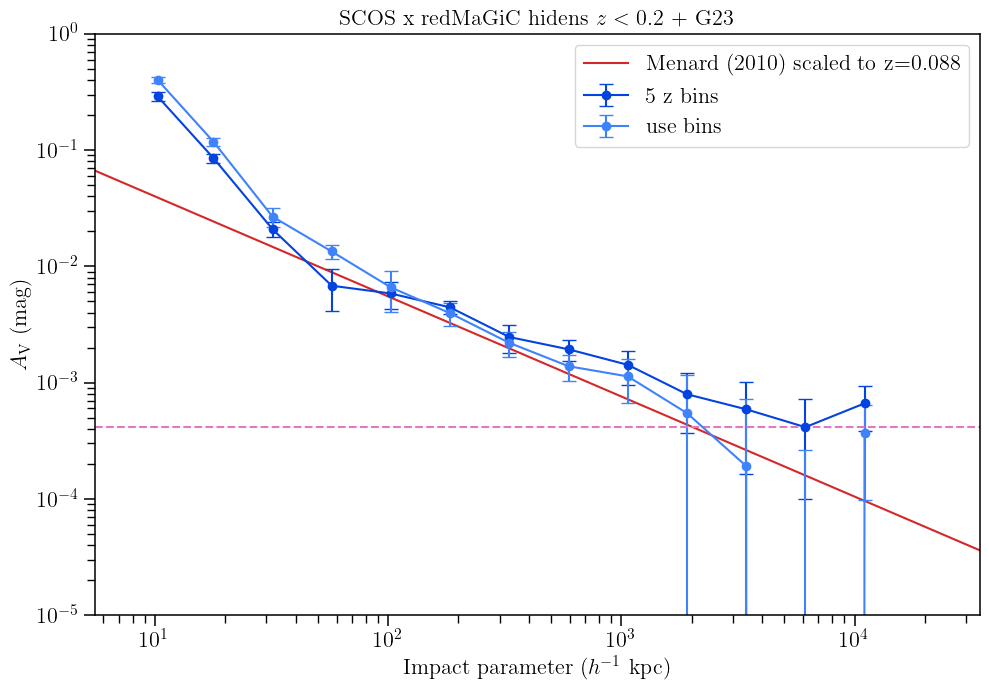

In [289]:
# Set z_theory and z_foreground levels
z_theory = 0.36 # Menard
z_fg = 0.088 # Filtered WISExSCOS

theory_kpc = cosmo.kpc_proper_per_arcmin(z_theory)
fg_gal_kpc = cosmo.kpc_proper_per_arcmin(z_fg)

theory_r_arcmin = np.logspace(-5,5,20)

theory_r = theory_r_arcmin * theory_kpc.value * cosmo.h
coeff = 5.5e-3
av_scale = 100
av = coeff * (theory_r/av_scale)**(-0.86)

# Converts us from arcminutes to h^-1 kpc 
# Menard relationship was in terms of h
scl = fg_gal_kpc.value * cosmo.h

fig, ax = plt.subplots(figsize=(10, 7), tight_layout=True)

ax.plot(theory_r, av, color='tab:red',
        label=f'Menard (2010) scaled to z={z_fg:.3f}')
# Part 1

# What it says
ax.errorbar(dk_g23['meanr']*scl, dust_hidens,
            yerr=dk_g23['sigma'], fmt='-o', capsize=5, 
            color='xkcd:blue', label=r'5 z bins')

ax.errorbar(dk_usebins['meanr']*scl, dust_hidens_usebins,
            yerr=dk_usebins['sigma'], fmt='-o', capsize=5, 
            color='xkcd:dodger blue', label=r'use bins')

'''
## What it says
ax.errorbar(dk_hitheta['meanr']*scl, dust_hitheta,
            yerr=dk_hitheta['sigma'], fmt='-o', capsize=5, 
            color='xkcd:teal', label=r'(ibid.) high impact parameter')

# Hi-z for reference
ax.errorbar(dk_OG['meanr']*scl, dust_hidens_OG,
            yerr=dk_OG['sigma'], fmt='-o', capsize=5, 
            color='xkcd:marine', label='OG hidens $z > 0.45$')

'''
ax.axhline(np.min(dust_hidens), linestyle='--', color='tab:pink')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.08*scl, 500*scl)
ax.set_ylim(1E-5, 1)
ax.set_xlabel(r'Impact parameter ($h^{-1}$ kpc)', fontsize=16)
ax.set_ylabel(r'$A_{\rm V}$ (mag)', fontsize=16)
ax.set_title(r'SCOS x redMaGiC hidens $z < 0.2$ + G23', fontsize=16)
ax.legend(fontsize=16)

fig.savefig('/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/dust_correlation_usebins.png')
#fig.savefig('/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/dust_correlation_April2024.png')


In [9]:
output_path = '/Users/j.mccleary/Research/dusty_halos/dusthalos/output/lowz_hidens_fg_X_hiz_bg/'
dk3 = Table.read(output_path+'LRG_dust_correlation_calzetti00_9bins_compensated_signal.txt', header_start=1, format='ascii')
dr3 = Table.read(output_path+'LRG_dust_correlation_calzetti00_9bins_bg_randoms.txt', header_start=1, format='ascii')
rr3 = Table.read(output_path+'LRG_dust_correlation_calzetti00_9bins_fgxbg_randoms.txt', header_start=1, format='ascii')
dust_lrg = dk3['kappa'] - dr3['kappa'] + rr3['kappa']

##
## SDSS
##
output_path = '/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/sdss/'
dk4 = Table.read(output_path+'dust_correlation_calzetti00_3zbins_compensated_signal.txt', header_start=1, format='ascii')
dr4 = Table.read(output_path+'dust_correlation_calzetti00_3zbins_bg_randoms.txt', header_start=1, format='ascii')
rr4 = Table.read(output_path+'dust_correlation_calzetti00_3zbins_fgxbg_randoms.txt', header_start=1, format='ascii')
dust_sdss = dk4['kappa'] - dr4['kappa'] + rr4['kappa']


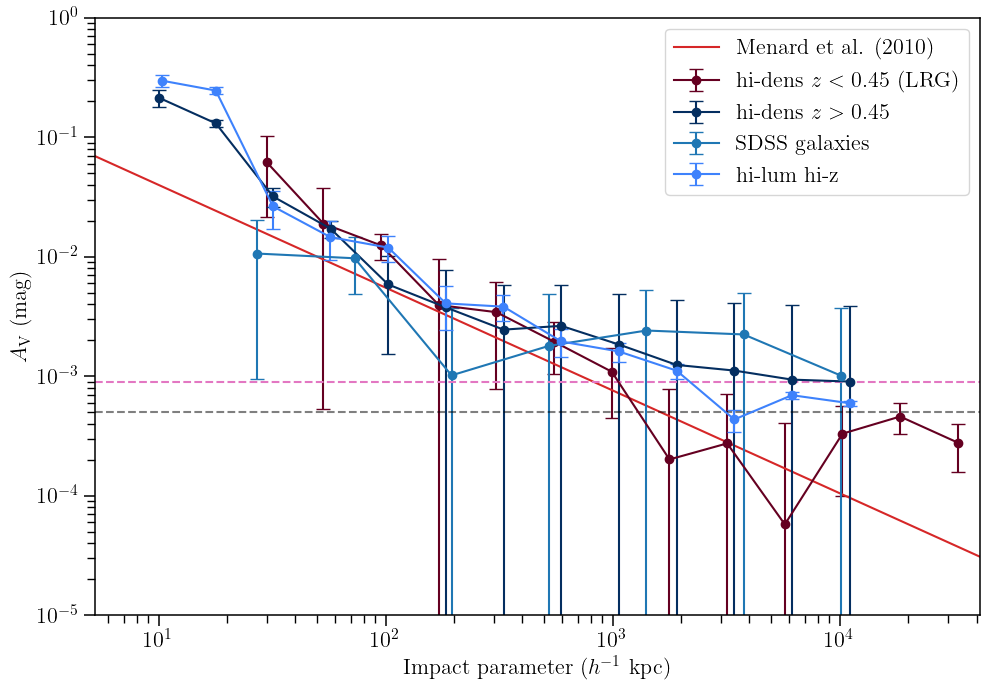

In [76]:
z_theory = 0.36 # Menard
z_fg = 0.350 # Filtered WISExSCOS

theory_kpc = cosmo.kpc_proper_per_arcmin(z_theory)
fg_gal_kpc = cosmo.kpc_proper_per_arcmin(z_fg)

theory_r_arcmin = np.logspace(-5,5,20)

theory_r = theory_r_arcmin * theory_kpc.value * cosmo.h
coeff = 5.5e-3
av_scale = 100
av = coeff * (theory_r/av_scale)**(-0.86)

# Converts us from arcminutes to h^-1 kpc 
# Menard relationship was in terms of h
scl = fg_gal_kpc.value * cosmo.h

fig, ax = plt.subplots(figsize=(10, 7), tight_layout=True)
ax.errorbar(dk3['meanr']*scl, dust_lrg,
            yerr=dk3['sigma'], fmt='-o', capsize=5, 
            color='xkcd:maroon', label=r'hi-dens $z<0.45$ (LRG)')
ax.plot(theory_r, av, color='tab:red',
        label=f'Menard et al. (2010)')

z_fg = 0.088 # Filtered WISExSCOS
fg_gal_kpc = cosmo.kpc_proper_per_arcmin(z_fg)
scl = fg_gal_kpc.value * cosmo.h

ax.errorbar(hidens_dk['meanr']*scl, dust_hidens,
            yerr=hidens_dk['sigma'], fmt='-o', capsize=5, 
            color='xkcd:marine', label=r'hi-dens $z>0.45$')
ax.errorbar(dk4['meanr']*scl, dust_sdss,
            yerr=dk4['sigma'], fmt='-o', capsize=5, 
            color='tab:blue', label=r'SDSS galaxies')
ax.errorbar(hiz_dk['meanr']*scl, dust_hiz,
            yerr=hiz_dk['sigma'], fmt='-o', capsize=5, 
            color='xkcd:dodger blue', label='hi-lum hi-z')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.076*scl, 600*scl)
ax.set_ylim(1E-5, 1)

ax.axhline(5e-4, linestyle='--', color='k', alpha=0.5)
ax.axhline(np.min(dust_hidens), linestyle='--', color='tab:pink')

ax.set_xlabel(r'Impact parameter ($h^{-1}$ kpc)', fontsize=16)
ax.set_ylabel(r'$A_{\rm V}$ (mag)', fontsize=16)
#ax.set_title('redMaGiC x redMaGiC', fontsize=16)
ax.legend(fontsize=16)

#fig.savefig('/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/dust_correlation_lrg.png')
#fig.savefig('/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/dust_correlation_ALL2.png')



 # Testing Gaia systematics


In [10]:
###
### Read in files 
###
output_path = '/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/systematics_testing/gaia_fg/'
dk_gaia1 = Table.read(output_path+'dustcorrel_hidens_g23_5zbins_compensated_signal.txt', header_start=1, format='ascii')
dr_gaia1 = Table.read(output_path+'dustcorrel_hidens_g23_5zbins_bg_randoms.txt', header_start=1, format='ascii')
fr_gaia1 = Table.read(output_path+'dustcorrel_hidens_g23_5zbins_fg_randoms.txt', header_start=1, format='ascii')
rr_gaia1 = Table.read(output_path+'dustcorrel_hidens_g23_5zbins_fgxbg_randoms.txt', header_start=1, format='ascii')

dk_gaia2 = Table.read(output_path+'dustcorrel_hiz_g23_5zbins_compensated_signal.txt', header_start=1, format='ascii')
dr_gaia2 = Table.read(output_path+'dustcorrel_hiz_g23_5zbins_bg_randoms.txt', header_start=1, format='ascii')
fr_gaia2 = Table.read(output_path+'dustcorrel_hiz_g23_5zbins_fg_randoms.txt', header_start=1, format='ascii')
rr_gaia2 = Table.read(output_path+'dustcorrel_hiz_g23_5zbins_fgxbg_randoms.txt', header_start=1, format='ascii')

###
### Now define signal 
### 

dust_gaia1 = dk_gaia1['kappa'] - dr_gaia1['kappa'] + rr_gaia1['kappa']
dust_gaia2 = dk_gaia2['kappa'] - dr_gaia2['kappa'] + rr_gaia2['kappa']


In [40]:
dk_gaia1

r_nom,meanr,meanlogr,kappa,sigma,weight,npairs
float64,float64,float64,float64,float64,float64,float64
0.13396,0.14435,-1.948,0.022154,0.020704,340.55,1716.0
0.24037,0.2579,-1.3682,0.0020955,0.020039,1197.5,6034.0
0.43133,0.46146,-0.78628,0.0015889,0.0088066,3707.4,18681.0
0.774,0.82737,-0.20214,-0.0088823,0.0057508,11579.0,58347.0
1.3889,1.4842,0.38253,0.0025332,0.0030837,36511.0,183970.0
2.4922,2.6615,0.96699,-0.0012232,0.0016834,114790.0,578410.0
4.4721,4.7797,1.5528,0.0021795,0.0012376,364130.0,1834800.0
8.0249,8.5861,2.1387,-0.00015537,0.0006053,1157300.0,5831300.0
14.4,15.416,2.7239,-0.0001053,0.00032545,3674500.0,18515000.0


In [392]:
## Try lstq regression... 

fit_gaia_hidens = stats.linregress(dk_gaia1['meanlogr'], dust_gaia1)
fit_gaia_hiz = stats.linregress(dk_gaia2['meanlogr'], dust_gaia2)

In [393]:
print("Hidens Gaia\n")
print(fit_gaia_hidens)
print("")

print("Hiz Gaia\n")
print(fit_gaia_hiz)
print("")


print(f"Gaia x high-z fit: {np.exp(fit_gaia_hiz[1]):.2e} * (meanr)^{fit_gaia_hiz[0]:.2f}")
print(f"Gaia x high-dens fit: {np.exp(fit_gaia_hidens[1]):.2e} * (meanr)^{fit_gaia_hidens[0]:.2f}")


Hidens Gaia

LinregressResult(slope=-0.0010014525765192368, intercept=0.0028608735656159684, rvalue=-0.34864962639771296, pvalue=0.24300592227257914, stderr=0.0008117115823681663, intercept_stderr=0.0021778226530279506)

Hiz Gaia

LinregressResult(slope=-0.0006154472446567547, intercept=0.001062112738593597, rvalue=-0.08467738003022668, pvalue=0.7832864626811469, stderr=0.0021835566622142913, intercept_stderr=0.005859066710258177)

Gaia x high-z fit: 1.00e+00 * (meanr)^-0.00
Gaia x high-dens fit: 1.00e+00 * (meanr)^-0.00


In [227]:
res2.params

array([-5.1851789 , -0.49926081])

In [330]:
def do_WLS_fit(this_dk, dust_rel, name=None, start=None, end=None, log=False):
    """
    Perform a weighted least-squares linear regression to
    data, taking care to transform the variables appropriately.

    Inputs
        this_dk: should be the 'compensated' treecorr output
        dust_rel: the corrected A_V relationship (dk-dr+rr)
        name: what are we calling it?
        start: exclude points with index < 'start' for fitting
        end: ibidem, but for points with index > 'end'
        log: if True, fit the relationship in log-space to stabilize the fits.
             Default is False.
    """

    ## Transform the dependent variable (fully compensated kappa)
    if log == True:
        Y = np.log(dust_rel[start:end])        
        ## Also need to transform the weights!
        weights_OG = 1/(this_dk['sigma'][start:end]**2)
        weight_scale = (1/(Y+1))**2
        weights = weights_OG * weight_scale
    
    ## Just do regular fit
    else:
        Y = dust_rel[start:end]
        weights = 1/(this_dk['sigma'][start:end]**2)
    
    ## If plotting X on a log-scale, which we are, 
    ## fit relationship on log scale
    X = this_dk['meanlogr'][start:end]

    ## Add intercept to abscissa
    X = sm.add_constant(X)

    ## Do fit
    mod_wls = sm.WLS(Y, X, weights=weights)
    res_wls = mod_wls.fit()

    ## Print results
    print("")
    print(f"Fit result: {name}")
    print("")
    print(res_wls.summary())

    return(res_wls)

In [102]:
res_gaia1 = do_WLS_fit(dk_gaia1, dust_gaia1, name='Gaia x high-dens', log=False)


Fit result: Gaia x high-dens

                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.006
Model:                            WLS   Adj. R-squared:                 -0.084
Method:                 Least Squares   F-statistic:                   0.06911
Date:                Thu, 18 Apr 2024   Prob (F-statistic):              0.798
Time:                        13:05:22   Log-Likelihood:                 69.568
No. Observations:                  13   AIC:                            -135.1
Df Residuals:                      11   BIC:                            -134.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0001

/Users/j.mccleary/Software/miniconda3/envs/jupyterlab/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1736: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=13
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


In [203]:
res_gaia2 = do_WLS_fit(dk_gaia2, dust_gaia2, name='Gaia x high-z', log=False)


Fit result: Gaia x high-z

                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.001
Model:                            WLS   Adj. R-squared:                 -0.090
Method:                 Least Squares   F-statistic:                  0.007414
Date:                Thu, 18 Apr 2024   Prob (F-statistic):              0.933
Time:                        14:26:38   Log-Likelihood:                 67.382
No. Observations:                  13   AIC:                            -130.8
Df Residuals:                      11   BIC:                            -129.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0001   

/Users/j.mccleary/Software/miniconda3/envs/jupyterlab/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1736: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=13
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


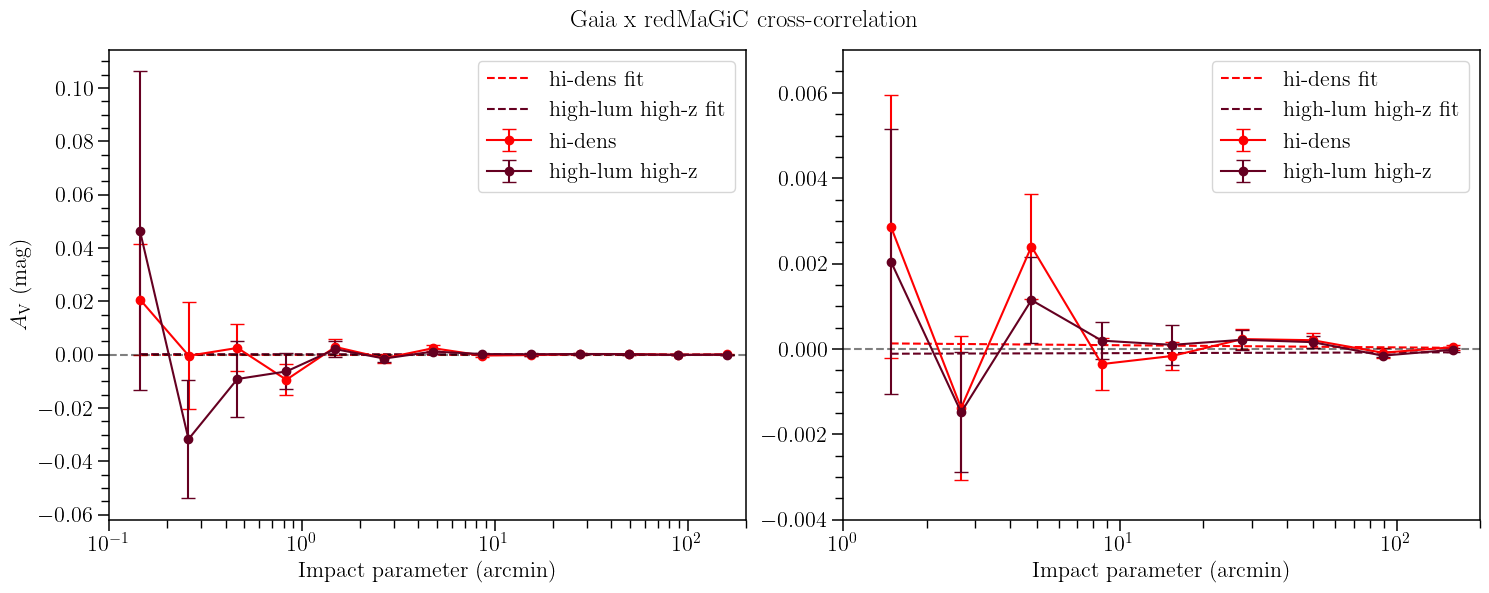

In [104]:
##
## Plot Gaia x redMaGiC results
##

## gaia x high-dens sample
a = res_gaia1.params[1] # Power
b = res_gaia1.params[0] # Coefficient
fit_gaia1 = a * dk_gaia1['meanlogr'] + b

# gaia x high-lum high-z sample
fit_gaia2 = res_gaia2.params[1] * dk_gaia2['meanlogr'] + res_gaia2.params[0]

fig, axs = plt.subplots(1, 2, figsize=(15, 6), tight_layout=True)

axs[0].errorbar(dk_gaia1['meanr'], dust_gaia1,
            yerr=dk_gaia1['sigma'], fmt='-o', capsize=5, 
            label=r'hi-dens', color='xkcd:fire engine red')
axs[0].plot(dk_gaia1['meanr'], fit_gaia2, ls='--', color='xkcd:fire engine red', 
        label='hi-dens fit')

axs[0].errorbar(dk_gaia2['meanr'], dust_gaia2,
            yerr=dk_gaia2['sigma'], fmt='-o', capsize=5, 
            label=r'high-lum high-z', color='xkcd:maroon')
axs[0].plot(dk_gaia1['meanr'], fit_gaia1, ls='--', color='xkcd:maroon', 
        label='high-lum high-z fit')

axs[0].set_xscale('log')
axs[0].set_xlim(0.1, 200)
axs[0].axhline(0, linestyle='--', color='k', alpha=0.5)

axs[0].set_xlabel(r'Impact parameter (arcmin)', fontsize=16)
axs[0].set_ylabel(r'$A_{\rm V}$ (mag)', fontsize=16)
axs[0].legend(fontsize=16)

### 
### Inset
###
axs[1].errorbar(dk_gaia1['meanr'][4:], dust_gaia1[4:],
            yerr=dk_gaia1['sigma'][4:], fmt='-o', capsize=5, 
            label=r'hi-dens', color='xkcd:fire engine red')
axs[1].plot(dk_gaia1['meanr'][4:], fit_gaia1[4:], ls='--', color='xkcd:fire engine red', 
        label='hi-dens fit')

axs[1].errorbar(dk_gaia2['meanr'][4:], dust_gaia2[4:],
            yerr=dk_gaia2['sigma'][4:], fmt='-o', capsize=5, 
            label=r'high-lum high-z', color='xkcd:maroon')
axs[1].plot(dk_gaia1['meanr'][4:], fit_gaia2[4:], ls='--', color='xkcd:maroon', 
        label='high-lum high-z fit')

axs[1].set_xscale('log')
axs[1].set_xlim(1, 200)
axs[1].set_ylim(-4e-3, 7e-3)
axs[1].axhline(0, linestyle='--', color='k', alpha=0.5)

axs[1].set_xlabel(r'Impact parameter (arcmin)', fontsize=16)
#axs[1].set_ylabel(r'$A_{\rm V}$ (mag)', fontsize=16)
axs[1].legend(fontsize=16)

fig.suptitle('Gaia x redMaGiC cross-correlation', fontsize=18)
fig.savefig('figures_update2/Gaia_redmagic_crosscorrel.png')

## OK, now try fit for real correlation

In [322]:
res_hidens = do_WLS_fit(dk_usebins, dust_hidens_usebins, 
                        name='hidens usebins', start=2, end=10, log=True)
print(res_hidens.params)
print(f"Fit: {np.exp(res_hidens.params[0]):.2e} * (meanr)^{res_hidens.params[1]:.2f}")


Fit result: hidens usebins

                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.965
Model:                            WLS   Adj. R-squared:                  0.959
Method:                 Least Squares   F-statistic:                     165.1
Date:                Thu, 18 Apr 2024   Prob (F-statistic):           1.37e-05
Time:                        18:23:45   Log-Likelihood:                 2.5756
No. Observations:                   8   AIC:                            -1.151
Df Residuals:                       6   BIC:                           -0.9924
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.7284  

/Users/j.mccleary/Software/miniconda3/envs/jupyterlab/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1736: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=8
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


In [331]:
res_hiz = do_WLS_fit(dk_hiz, dust_hiz, name='high-lum high-z', start=2, end=9, log=True)
print(res_hiz.params)
print(f"Fit: {np.exp(res_hiz.params[0]):.2e} * (meanr)^{res_hiz.params[1]:.2f}")


Fit result: high-lum high-z

                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.918
Model:                            WLS   Adj. R-squared:                  0.902
Method:                 Least Squares   F-statistic:                     55.93
Date:                Thu, 18 Apr 2024   Prob (F-statistic):           0.000675
Time:                        18:25:34   Log-Likelihood:               -0.22703
No. Observations:                   7   AIC:                             4.454
Df Residuals:                       5   BIC:                             4.346
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -5.4068 

/Users/j.mccleary/Software/miniconda3/envs/jupyterlab/lib/python3.11/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 7 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [366]:
## Do LRG, too! 

res_lrg = do_WLS_fit(dk_lrg, dust_lrg, name='LRG', log=True)
print(res_lrg.params)
print(f"Fit: {np.exp(res_lrg.params[0]):.2e} * (meanr)^{res_lrg.params[1]:.2f}")


Fit result: LRG

                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.659
Model:                            WLS   Adj. R-squared:                  0.628
Method:                 Least Squares   F-statistic:                     21.26
Date:                Thu, 18 Apr 2024   Prob (F-statistic):           0.000752
Time:                        18:45:40   Log-Likelihood:                -18.317
No. Observations:                  13   AIC:                             40.63
Df Residuals:                      11   BIC:                             41.76
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -6.4254      0.461  

/Users/j.mccleary/Software/miniconda3/envs/jupyterlab/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1736: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=13
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


In [395]:
linregress_lrg = stats.linregress(
    dk_lrg['meanlogr'], np.log(dust_lrg))
linregress_hiz = stats.linregress(
    dk_hiz['meanlogr'][3:9], np.log(dust_hiz[3:9]))
linregress_hidens = stats.linregress(
    dk_usebins['meanlogr'][3:9], np.log(dust_hidens_usebins[3:9]))

print("LRG params")
print(linregress_lrg)
print("")

print("high-dens params")
print(linregress_hidens)
print("")

print("high-z params")
print(linregress_hiz)
print("")


print(f"LRG fit: {np.exp(linregress_lrg[1]):.2e} * (meanr)^{linregress_lrg[0]:.2f}")
print(f"High-z fit: {np.exp(linregress_hiz[1]):.2e} * (meanr)^{linregress_hiz[0]:.2f}")
print(f"High-dens fit: {np.exp(linregress_hidens[1]):.2e} * (meanr)^{linregress_hidens[0]:.2f}")

print(f"intercept stderr: {np.exp(linregress_hidens.intercept_stderr):.2e}")

LRG params
LinregressResult(slope=-0.8377100193384093, intercept=-5.179418971741271, rvalue=-0.9502184084462224, pvalue=6.597327871297423e-07, stderr=0.0828228063373637, intercept_stderr=0.22224755164343538)

high-dens params
LinregressResult(slope=-0.8610262906855469, intercept=-4.639999874542349, rvalue=-0.9887988924600707, pvalue=0.00018749454276627064, stderr=0.06498368927847681, intercept_stderr=0.10456383552782016)

high-z params
LinregressResult(slope=-0.8509664962770174, intercept=-5.229626006644003, rvalue=-0.966496017921478, pvalue=0.0016649708310486101, stderr=0.11299966252694332, intercept_stderr=0.18182510704832494)

LRG fit: 5.63e-03 * (meanr)^-0.84
High-z fit: 5.36e-03 * (meanr)^-0.85
High-dens fit: 9.66e-03 * (meanr)^-0.86
intercept stderr: 1.11e+00


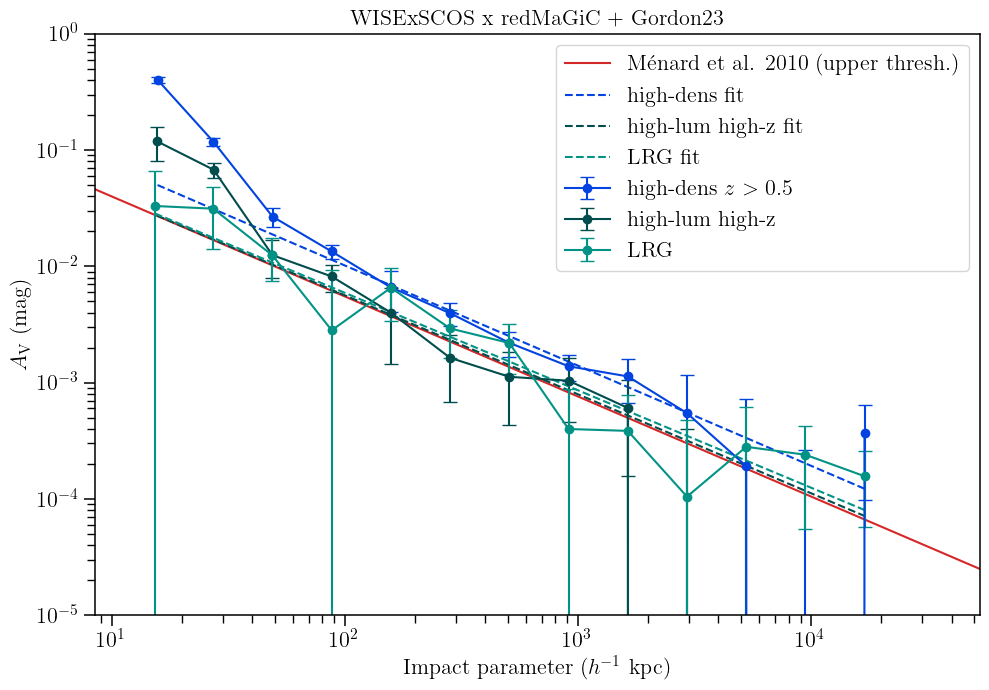

In [397]:

#Set z_theory and z_foreground levels
z_theory = 0.36 # Menard
z_fg = 0.144 # Filtered WISExSCOS

theory_r_arcmin = np.logspace(-5, 5, 20)

# Converts us from arcminutes to h^-1 kpc 
# Menard relationship was in terms of h
theory_kpc = cosmo.kpc_proper_per_arcmin(z_theory)
fg_gal_kpc = cosmo.kpc_proper_per_arcmin(z_fg)
scl = fg_gal_kpc.value * cosmo.h

'''
## high-z sample
a = res_hiz.params[1]; A = np.exp(a) # Power
b = res_hiz.params[0]; B = np.exp(b) # Coefficient
fit_hiz = B * (dk_hiz['meanr']**a)
fit_hiz2 = B * (theory_r_arcmin / cosmo.h)**a

## high-density sample
a = res_hidens.params[1]; A = np.exp(a) # Power
b = res_hidens.params[0]; B = np.exp(b) # Coefficient
fit_hidens = B * (dk_usebins['meanr']**a) 
fit_hidens2 = B * (theory_r_arcmin / cosmo.h)**a

## LRG
a = res_lrg.params[1]; A = np.exp(a) # Power
b = res_lrg.params[0]; B = np.exp(b) # Coefficient
fit_lrg = B * (dk_lrg['meanr']**a) 
fit_lrg2 = B * (theory_r_arcmin / cosmo.h)**a
'''

## high-z sample
a = linregress_hiz[0]; A = np.exp(a) # Power
b = linregress_hiz[1]; B = np.exp(b) # Coefficient
fit_hiz = B * (dk_hiz['meanr']**a)
fit_hiz2 = B * (theory_r_arcmin / cosmo.h)**a

## high-density sample
a = linregress_hidens[0]; A = np.exp(a) # Power
b = linregress_hidens[1]; B = np.exp(b) # Coefficient
fit_hidens = B * (dk_usebins['meanr']**a) 
fit_hidens2 = B * (theory_r_arcmin / cosmo.h)**a

## LRG
a = linregress_lrg[0]; A = np.exp(a) # Power
b = linregress_lrg[1]; B = np.exp(b) # Coefficient
fit_lrg = B * (dk_lrg['meanr']**a) 
fit_lrg2 = B * (theory_r_arcmin / cosmo.h)**a



theory_r = theory_r_arcmin * theory_kpc.value * cosmo.h
coeff = 5.5e-3
av_scale = 100
av = coeff * (theory_r/av_scale)**(-0.86)
#av = coeff * (theory_r/av_scale)**(-0.7)

fig, ax = plt.subplots(figsize=(10, 7), tight_layout=True)

ax.plot(theory_r, av, color='tab:red',
        label=r"M\'{e}nard et al. 2010 (upper thresh.)")


# What it says
ax.errorbar(dk_usebins['meanr']*scl, dust_hidens_usebins,
            yerr=dk_usebins['sigma'], fmt='-o', capsize=5, 
            color='xkcd:blue', label=r'high-dens $z>0.5$')
ax.plot(dk_g23['meanr']*scl, fit_hidens, linestyle='--', color='xkcd:blue', label=r'high-dens fit')
#ax.plot(theory_r*cosmo.h, fit_hidens2, linestyle='--', label=r'high-dens fit 2')

ax.errorbar(dk_hiz['meanr']*scl, dust_hiz, 
            yerr=dk_hiz['sigma'], fmt='-o', capsize=5, 
            color='xkcd:dark teal', label=r'high-lum high-z')
ax.plot(dk_hiz['meanr']*scl, fit_hiz, linestyle='--', color='xkcd:dark teal', label=r'high-lum high-z fit')
#ax.plot(theory_r*cosmo.h, fit_hiz2, linestyle='--', label=r'high-lum high-z fit 2')

ax.errorbar(dk_lrg['meanr']*scl, dust_lrg, 
            yerr=dk_lrg['sigma'], fmt='-o', capsize=5, 
            color='xkcd:teal', label=r'LRG')
ax.plot(dk_lrg['meanr']*scl, fit_lrg, linestyle='--', color='xkcd:teal', label=r'LRG fit')


ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.08*scl, 500*scl)
ax.set_ylim(1E-5, 1)
ax.set_xlabel(r'Impact parameter ($h^{-1}$ kpc)', fontsize=16)
ax.set_ylabel(r'$A_{\rm V}$ (mag)', fontsize=16)
ax.set_title(r'WISExSCOS x redMaGiC + Gordon23', fontsize=16)
ax.legend(fontsize=16)

fig.savefig(
    '/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/writeup/figures_update2/'+
    'dust_correlation_rmz_withfit.png'
)

